In [3]:
import warnings
import numpy as np
import pandas as pd

np.random.seed(42)
warnings.filterwarnings("ignore")

# PART 0: LOAD & PRE-FLIGHT CHECKS

In [4]:
import subprocess
import sys

df = pd.read_parquet("df_final_enriched.parquet")
df["Date"] = pd.to_datetime(df["Date"])

# Sort chronologically to maintain time series order
df = df.sort_values(["Product_Code", "Warehouse", "Date"]).reset_index(drop=True)

print(f"  Loaded : {len(df):,} rows | {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"  Products: {df['Product_Code'].nunique()} | Warehouses: {df['Warehouse'].nunique()}")

REQUIRED_CONTEXT_COLS = {
    "Calendar":       ["Week_Of_Year", "Month", "Quarter", "Year", "Month_Sin", "Month_Cos"],
    "Macroeconomics": ["Copper_Price_Lag1", "Aluminum_Price_Lag1",
                       "Oil_Price_Lag1", "USD_Index_Lag1"],
}

missing_cols = [
    f"{col} ({cat})"
    for cat, cols in REQUIRED_CONTEXT_COLS.items()
    for col in cols
    if col not in df.columns
]
if missing_cols:
    raise ValueError(
        f"[Error] Missing contextual features: {', '.join(missing_cols)}.\n"
        "Please run the Feature Enrichment step first."
    )
print("  [OK] All contextual features are valid.")

  Loaded : 352,156 rows | 2011-01-10 → 2017-01-09
  Products: 2160 | Warehouses: 4
  [OK] All contextual features are valid.


# PART 1: CHRONOLOGICAL SPLIT CUTOFFS

In [5]:
all_dates    = np.sort(df["Date"].unique())
n_dates      = len(all_dates)
train_cutoff = all_dates[int(n_dates * 0.70)]
val_cutoff   = all_dates[int(n_dates * 0.85)]

print(f"  Total unique weeks : {n_dates}")
print(f"  Train  : < {pd.Timestamp(train_cutoff).date()}")
print(f"  Val    : [{pd.Timestamp(train_cutoff).date()}, {pd.Timestamp(val_cutoff).date()})")
print(f"  Test   : >= {pd.Timestamp(val_cutoff).date()}")


  Total unique weeks : 277
  Train  : < 2015-06-08
  Val    : [2015-06-08, 2016-03-28)
  Test   : >= 2016-03-28


# PART 2: DEMAND BEHAVIOR FEATURES

In [6]:
def add_demand_behavior_features(g: pd.DataFrame) -> pd.DataFrame:
    g = g.sort_values("Date").copy()
    d = g["Order_Demand"]

    g["Is_Zero_Demand"] = (d == 0).astype(int)

    # Track weeks elapsed since the last non-zero demand order
    had_order_prev = (d.shift(1) > 0)
    counter, weeks_since = 1, []
    for had in had_order_prev:
        if pd.isna(had):
            weeks_since.append(1)
        elif had:
            counter = 1
            weeks_since.append(counter)
        else:
            counter += 1
            weeks_since.append(counter)
    g["Weeks_Since_Last_Order"] = weeks_since

    return g


if "Is_Zero_Demand" not in df.columns:
    print("  Computing demand behavior features...")
    df = pd.concat(
        [add_demand_behavior_features(g)
         for _, g in df.groupby(["Product_Code", "Warehouse"], sort=False)],
        ignore_index=True,
    )
    df = df.sort_values(["Product_Code", "Warehouse", "Date"]).reset_index(drop=True)
else:
    print("  Already exists, skipping.")

print(f"  Is_Zero_Demand rate          : {df['Is_Zero_Demand'].mean():.1%}")
print(f"  Weeks_Since_Last_Order (p50) : {df['Weeks_Since_Last_Order'].median():.0f}")


  Already exists, skipping.
  Is_Zero_Demand rate          : 53.7%
  Weeks_Since_Last_Order (p50) : 2


# PART 3: MISSING VALUE IMPUTATION

In [7]:
df = df.sort_values(["Product_Code", "Warehouse", "Date"]).reset_index(drop=True)

df["Has_52W_History"] = (~df["Demand_Lag52W"].isna()).astype(int)
df["Has_YoY_Data"]    = (~df["Demand_YoY_Growth"].isna()).astype(int)

cum = df.groupby(["Product_Code", "Warehouse"]).cumcount()

df.loc[cum < 52, "Demand_Lag52W"]      = df.loc[cum < 52, "Demand_Lag52W"].fillna(0)
df.loc[cum < 53, "Demand_YoY_Growth"]  = df.loc[cum < 53, "Demand_YoY_Growth"].fillna(0)

if "Demand_Expanding_Mean" in df.columns:
    df["Demand_Expanding_Mean"] = df["Demand_Expanding_Mean"].fillna(0)

LAG_COLS = [
    "Demand_Lag1W",      "Demand_Lag2W",      "Demand_Lag4W",
    "Demand_Lag8W",      "Demand_Lag12W",     "Demand_Lag52W",
    "Demand_RollMean4W", "Demand_RollMean8W", "Demand_RollMean12W",
    "Demand_RollStd4W",  "Demand_RollStd8W",  "Demand_RollStd12W",
    "Demand_Trend",      "Demand_YoY_Growth",
]
if "Demand_Expanding_Mean" in df.columns:
    LAG_COLS.append("Demand_Expanding_Mean")

existing_lag_cols = [c for c in LAG_COLS if c in df.columns]
df[existing_lag_cols] = df[existing_lag_cols].fillna(0)

remaining_nan = df[existing_lag_cols].isna().sum().sum()
print(f"  Remaining NaN in lag cols: {remaining_nan}  ({'OK' if remaining_nan == 0 else 'CHECK'})")


  Remaining NaN in lag cols: 0  (OK)


# PART 4: CHRONOLOGICAL SPLIT


In [8]:
train_df = df[df["Date"] <  train_cutoff].copy()
val_df   = df[(df["Date"] >= train_cutoff) & (df["Date"] < val_cutoff)].copy()
test_df  = df[df["Date"] >= val_cutoff].copy()

for name, split in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"  {name:5s}: {split['Date'].min().date()} → {split['Date'].max().date()}"
          f"  ({len(split):,} rows)")

cold_val  = set(val_df["Product_Code"])  - set(train_df["Product_Code"])
cold_test = set(test_df["Product_Code"]) - set(train_df["Product_Code"])
print(f"\n  Cold-start products (val)  : {len(cold_val)}")
print(f"  Cold-start products (test) : {len(cold_test)}")


  Train: 2011-01-10 → 2015-06-01  (240,414 rows)
  Val  : 2015-06-08 → 2016-03-21  (57,744 rows)
  Test : 2016-03-28 → 2017-01-09  (53,998 rows)

  Cold-start products (val)  : 28
  Cold-start products (test) : 43


# PART 5: DTW CLUSTERING — FIT ON TRAIN ONLY

In [9]:
try:
    from tslearn.clustering import TimeSeriesKMeans, silhouette_score as ts_silhouette
    TSLEARN_AVAILABLE = True
except ImportError:
    print("  [Warning] tslearn not installed. Skipping DTW clustering.")
    print("            Install using: pip install tslearn")
    TSLEARN_AVAILABLE = False


def _build_demand_matrix(source_df: pd.DataFrame):
    # Pivot long -> wide, run row-wise Z-normalization, and return a 3D tensor for tslearn.

    pivot = source_df.pivot_table(
        index=["Product_Code", "Warehouse"],
        columns="Date",
        values="Order_Demand",
        fill_value=0,
    ).fillna(0)
    idx = pivot.index.to_frame(index=False)
    
    # Z-normalize each series independently across the time axis
    vals = pivot.values
    means = vals.mean(axis=1, keepdims=True)
    stds = vals.std(axis=1, keepdims=True)
    stds[stds == 0] = 1.0  # Avoid division by zero for constant or all-zero series
    scaled = (vals - means) / stds
    
    X_ts = scaled.reshape(scaled.shape[0], scaled.shape[1], 1)
    return X_ts, idx, pivot.columns


def _find_optimal_k(X_ts, k_range, seed=42):
    sample_size = min(len(X_ts), 500)
    best_k, best_score, scores = k_range[0], -1.0, {}

    print("  Evaluating silhouette scores...")
    for k in k_range:
        model = TimeSeriesKMeans(
            n_clusters=k, metric="dtw",
            max_iter=10, n_init=1,
            random_state=seed, n_jobs=-1, verbose=False,
        )
        labels = model.fit_predict(X_ts)
        score  = ts_silhouette(
            X_ts, labels, metric="dtw",
            sample_size=sample_size, random_state=seed, n_jobs=-1,
        )
        scores[k] = score
        print(f"    k={k} → silhouette={score:.4f}")
        if score > best_score:
            best_score, best_k = score, k

    print(f"  → Optimal k={best_k}  (silhouette={best_score:.4f})")
    return best_k, scores


def _assign_cluster_nearest_centroid(X_new, model):

    centroids = model.cluster_centers_.squeeze(axis=-1)  # (k, T_centroid)
    X_flat    = X_new.squeeze(axis=-1)                   # (n, T_new)

    T_centroid = centroids.shape[1]
    T_new      = X_flat.shape[1]

    # Pad or truncate series to match the training centroid's timestep length
    if T_new >= T_centroid:
        X_flat = X_flat[:, :T_centroid]
    else:
        pad_width = T_centroid - T_new
        X_flat = np.pad(X_flat, ((0, 0), (0, pad_width)), constant_values=0)

    # Determine assignments based on closest centroid Euclidean distance
    dists = np.linalg.norm(X_flat[:, None, :] - centroids[None, :, :], axis=2)  # (n, k)
    return np.argmin(dists, axis=1)


if TSLEARN_AVAILABLE:
    X_train_ts, train_idx, train_date_cols = _build_demand_matrix(train_df)
    print(f"  Train demand matrix: {X_train_ts.shape[0]} series × {X_train_ts.shape[1]} timesteps")

    best_k, _ = _find_optimal_k(X_train_ts, k_range=[2, 3, 4, 5, 6], seed=42)

    print(f"\n  Fitting final TimeSeriesKMeans (k={best_k}, metric=dtw)...")
    final_model = TimeSeriesKMeans(
        n_clusters=best_k, metric="dtw",
        max_iter=10, n_init=2,
        random_state=42, n_jobs=-1, verbose=False,
    )
    final_model.fit(X_train_ts)
    train_idx["Demand_Cluster"] = final_model.labels_.astype(int)

    X_val_ts, val_idx, _ = _build_demand_matrix(val_df)
    val_idx["Demand_Cluster"] = _assign_cluster_nearest_centroid(X_val_ts, final_model)

    X_test_ts, test_idx, _ = _build_demand_matrix(test_df)
    test_idx["Demand_Cluster"] = _assign_cluster_nearest_centroid(X_test_ts, final_model)

    # Combine indices while keeping first assignments and resolving cold-starts
    all_cluster_labels = pd.concat([train_idx, val_idx, test_idx], ignore_index=True)
    all_cluster_labels = all_cluster_labels.drop_duplicates(["Product_Code", "Warehouse"])

    if "Demand_Cluster" in df.columns:
        df = df.drop(columns=["Demand_Cluster"])
    df = df.merge(all_cluster_labels[["Product_Code", "Warehouse", "Demand_Cluster"]],
                  on=["Product_Code", "Warehouse"], how="left")

    train_df = df[df["Date"] <  train_cutoff].copy()
    val_df   = df[(df["Date"] >= train_cutoff) & (df["Date"] < val_cutoff)].copy()
    test_df  = df[df["Date"] >= val_cutoff].copy()

    print(f"\n  Cluster distribution (series count):")
    dist = all_cluster_labels["Demand_Cluster"].value_counts().sort_index()
    for cid, cnt in dist.items():
        print(f"    Cluster {cid}: {cnt} series ({cnt / dist.sum():.1%})")

    all_cluster_labels.to_parquet("cluster_labels.parquet", index=False)
    print("\n  Saved: cluster_labels.parquet")

else:
    df["Demand_Cluster"] = 0
    train_df = df[df["Date"] <  train_cutoff].copy()
    val_df   = df[(df["Date"] >= train_cutoff) & (df["Date"] < val_cutoff)].copy()
    test_df  = df[df["Date"] >= val_cutoff].copy()
    print("  [Fallback] Demand_Cluster = 0 for all data (tslearn is unavailable).")


  Train demand matrix: 2792 series × 193 timesteps
  Evaluating silhouette scores...
    k=2 → silhouette=0.1767
    k=3 → silhouette=0.1141
    k=4 → silhouette=0.1058
    k=5 → silhouette=0.0923
    k=6 → silhouette=0.0768
  → Optimal k=2  (silhouette=0.1767)

  Fitting final TimeSeriesKMeans (k=2, metric=dtw)...

  Cluster distribution (series count):
    Cluster 0: 1755 series (61.6%)
    Cluster 1: 1094 series (38.4%)

  Saved: cluster_labels.parquet



 Centroids (Z-normalized)
Date  2011-01-10  2011-06-06  2011-06-27  2011-09-05  2011-10-03  2011-10-24  \
0         -0.365      -0.413      -0.361      -0.363      -0.363      -0.363   
1         -0.254      -0.204      -0.212      -0.212      -0.211      -0.211   

Date  2011-10-31  2011-11-07  2011-11-21  2011-11-28  ...  2015-03-30  \
0         -0.363      -0.363      -0.363      -0.363  ...      -0.120   
1         -0.209      -0.211      -0.211      -0.211  ...      -0.129   

Date  2015-04-06  2015-04-13  2015-04-20  2015-04-27  2015-05-04  2015-05-11  \
0         -0.295      -0.376       0.612      -0.277       1.335      -0.191   
1         -0.219       0.111      -0.189       0.368      -0.183       1.366   

Date  2015-05-18  2015-05-25  2015-06-01  
0         -0.387      -0.302       0.181  
1         -0.105      -0.214       0.127  

[2 rows x 193 columns]


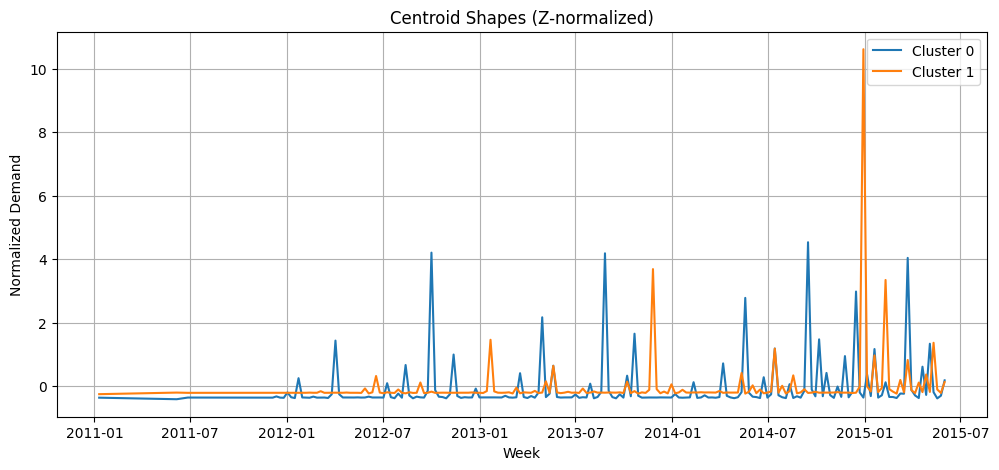

In [15]:
centroids = final_model.cluster_centers_.squeeze(axis=-1)  # shape: (n_clusters, n_timesteps)

centroids_df = pd.DataFrame(centroids, columns=train_date_cols)
print("\n Centroids (Z-normalized)")
print(centroids_df.round(3))   

import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
for i in range(centroids.shape[0]):
    plt.plot(train_date_cols, centroids[i], label=f'Cluster {i}')
plt.title('Centroid Shapes (Z-normalized)')
plt.xlabel('Week')
plt.ylabel('Normalized Demand')
plt.legend()
plt.grid(True)
plt.show()

In [16]:
print("\n Peak Week(s) per Cluster ")
for i in range(centroids.shape[0]):
    peak_idx = np.argmax(centroids[i])          
    peak_week = train_date_cols[peak_idx]       
    peak_value = centroids[i][peak_idx]
    print(f"Cluster {i}: Peak at {peak_week} (index {peak_idx}) with {peak_value:.3f}")

    top3_idx = np.argsort(centroids[i])[-3:][::-1]
    top3_weeks = [train_date_cols[idx] for idx in top3_idx]
    print(f" Top 3 week: {top3_weeks}")


 Peak Week(s) per Cluster 
Cluster 0: Peak at 2014-09-15 00:00:00 (index 155) with 4.535
 Top 3 week: [Timestamp('2014-09-15 00:00:00'), Timestamp('2012-10-01 00:00:00'), Timestamp('2013-08-26 00:00:00')]
Cluster 1: Peak at 2014-12-29 00:00:00 (index 170) with 10.619
 Top 3 week: [Timestamp('2014-12-29 00:00:00'), Timestamp('2013-11-25 00:00:00'), Timestamp('2015-02-09 00:00:00')]


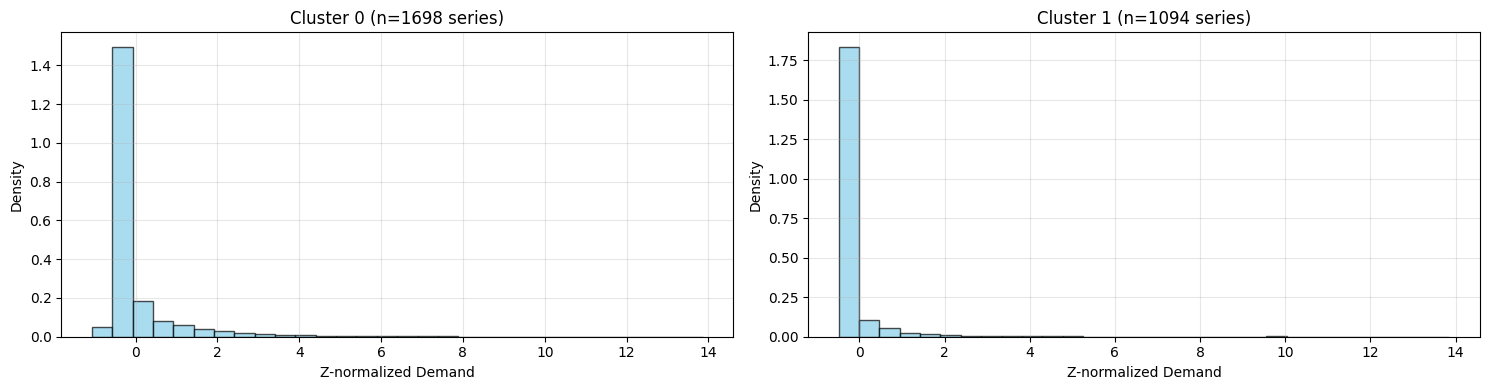

Cluster 0: 1,755 series (61.6%)
Cluster 1: 1,094 series (38.4%)


In [21]:
fig, axes = plt.subplots(1, best_k, figsize=(15, 4))

if best_k == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i in range(best_k):
    cluster_data = X_train_ts[final_model.labels_ == i].squeeze()
    axes[i].hist(cluster_data.flatten(), bins=30, density=True,
                 alpha=0.7, color='skyblue', edgecolor='black')
    axes[i].set_title(f'Cluster {i} (n={cluster_data.shape[0]} series)')
    axes[i].set_xlabel('Z-normalized Demand')
    axes[i].set_ylabel('Density')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

dist = all_cluster_labels["Demand_Cluster"].value_counts().sort_index()
total = dist.sum()
for cid, cnt in dist.items():
    print(f"Cluster {cid}: {cnt:,} series ({cnt/total:.1%})")

# PART 6: TARGET ENCODING — FIT ON TRAIN ONLY

In [8]:
def target_encode(
    train_df:    pd.DataFrame,
    apply_df:    pd.DataFrame,
    col:         str,
    target:      str   = "Order_Demand",
    smoothing:   float = 20.0,
    global_mean: float = None,
) -> pd.Series:
    if global_mean is None:
        global_mean = train_df[target].mean()

    stats = (
        train_df.groupby(col)[target]
        .agg(["mean", "count"])
        .rename(columns={"mean": "grp_mean", "count": "grp_cnt"})
    )
    stats["encoded"] = (
        (stats["grp_cnt"] * stats["grp_mean"] + smoothing * global_mean)
        / (stats["grp_cnt"] + smoothing)
    )
    return apply_df[col].map(stats["encoded"]).fillna(global_mean)


global_mean = train_df["Order_Demand"].mean()
print(f"  Global mean (train) : {global_mean:.2f}")

for split_df in [train_df, val_df, test_df]:
    split_df["Product_Code_TE"] = target_encode(
        train_df, split_df, "Product_Code", global_mean=global_mean)
    split_df["Warehouse_TE"] = target_encode(
        train_df, split_df, "Warehouse",    global_mean=global_mean)

print(f"  Product_Code_TE unique (train) : {train_df['Product_Code_TE'].nunique()}")
print(f"  Warehouse_TE unique (train)    : {train_df['Warehouse_TE'].nunique()}")



  Global mean (train) : 1703.34
  Product_Code_TE unique (train) : 2070
  Warehouse_TE unique (train)    : 4


# PART 7: DEFINE FEATURE SET & ASSERTIONS

In [9]:
DROP_COLS   = {"Product_Code", "Warehouse", "Date", "Order_Demand"}
FEATURE_COLS = [c for c in train_df.columns if c not in DROP_COLS]
TARGET_COL   = "Order_Demand"

assert "Demand_Cluster" in FEATURE_COLS, "Demand_Cluster is missing from FEATURE_COLS!"

X_train, y_train = train_df[FEATURE_COLS], train_df[TARGET_COL]
X_val,   y_val   = val_df[FEATURE_COLS],   val_df[TARGET_COL]
X_test,  y_test  = test_df[FEATURE_COLS],  test_df[TARGET_COL]

print(f"  Total features : {len(FEATURE_COLS)}")
print(f"  Feature list   :")
for i, f in enumerate(FEATURE_COLS):
    print(f"    {i+1:3d}. {f}")

assert X_train.isna().sum().sum() == 0, "NaN values present in X_train!"
assert X_val.isna().sum().sum()   == 0, "NaN values present in X_val!"
assert X_test.isna().sum().sum()  == 0, "NaN values present in X_test!"
print("\n  [OK] No NaN values found in X_train / X_val / X_test.")

assert train_df["Date"].max() < val_df["Date"].min(),   "Train/Val date overlap!"
assert val_df["Date"].max()   < test_df["Date"].min(),  "Val/Test date overlap!"
print("  [OK] No chronological leakage between splits.")


  Total features : 50
  Feature list   :
      1. Copper_Price_Lag1
      2. Aluminum_Price_Lag1
      3. Oil_Price_Lag1
      4. USD_Index_Lag1
      5. SP500_Lag1
      6. Industrial_ETF_Lag1
      7. Industrial_Production_Lag1
      8. Capacity_Utilization_Lag1
      9. Durable_Goods_Orders_Lag1
     10. PPI_All_Commodities_Lag1
     11. Crude_Oil_WTI_Lag1
     12. Consumer_Sentiment_Lag1
     13. Fed_Funds_Rate_Lag1
     14. Treasury_10Y_Lag1
     15. Copper_Aluminum_Ratio_Lag1
     16. Copper_Price_Momentum4W_Lag1
     17. Aluminum_Price_Momentum4W_Lag1
     18. Oil_Price_Momentum4W_Lag1
     19. Yield_Spread_Lag1
     20. Week_Of_Year
     21. Month
     22. Quarter
     23. Year
     24. Month_Sin
     25. Month_Cos
     26. Week_Sin
     27. Week_Cos
     28. Is_Quarter_End
     29. Demand_Lag1W
     30. Demand_Lag2W
     31. Demand_Lag4W
     32. Demand_Lag8W
     33. Demand_Lag12W
     34. Demand_Lag52W
     35. Demand_RollMean4W
     36. Demand_RollStd4W
     37. Demand_Roll

# PART 8: SAVE PREPROCESSED SPLITS

In [10]:
train_df.to_parquet("train_preprocessed.parquet", index=False)
val_df.to_parquet("val_preprocessed.parquet",     index=False)
test_df.to_parquet("test_preprocessed.parquet",   index=False)

print("  Saved: train_preprocessed.parquet")
print("  Saved: val_preprocessed.parquet")
print("  Saved: test_preprocessed.parquet")


  Saved: train_preprocessed.parquet
  Saved: val_preprocessed.parquet
  Saved: test_preprocessed.parquet


# PART 10: SAVE PIPELINE METADATA

In [11]:

import json

meta = {
    "train_cutoff": str(pd.Timestamp(train_cutoff).date()),
    "val_cutoff":   str(pd.Timestamp(val_cutoff).date()),
    "best_k":       int(best_k) if TSLEARN_AVAILABLE else 1,
    "global_mean":  float(global_mean),
    "feature_cols": FEATURE_COLS,
}
with open("pipeline_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print("  Saved: pipeline_meta.json")

  Saved: pipeline_meta.json
